# Projeto - Regressão Linear

Neste projeto foi usado uma base de imóveis para alugar, precisamos desenvolver um modelo de regressão linear múltipla para conseguir prever o preço de imóveis dadas as variáveis independentes do modelo.

Legenda dos dados:

*   **Valor_Aluguel** : valor Total pago no aluguel

*   **Valor_Condominio** : Valor do Condomínio.

*   **Metragem** : Metragem do Apartamento.

*   **N_Quartos** : Número de Quartos do Imóvel.

*   **N_banheiros** : Número de banheiros.

*   **N_Suites** : Número de Suítes.

*   **N_Vagas** : Número de Vagas.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("ALUGUEL.csv", delimiter=';')

In [3]:
df.head()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0


### Primerira etapa de pré processamento dos dados.

In [4]:
df.dtypes

Valor_Aluguel       int64
Valor_Condominio    int64
Metragem            int64
N_Quartos           int64
N_banheiros         int64
N_Suites            int64
N_Vagas             int64
dtype: object

In [5]:
df.isnull().sum()

Valor_Aluguel       0
Valor_Condominio    0
Metragem            0
N_Quartos           0
N_banheiros         0
N_Suites            0
N_Vagas             0
dtype: int64

### Segunda etapa de pré processamento dos dados.

In [6]:
df.describe()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
count,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.00000
mean,2966.596140,811.538109,88.506178,2.300153,2.095932,1.016660,1.44176
std,2948.720385,796.564846,61.567505,0.826615,0.983812,0.874204,0.86993
min,480.000000,0.000000,30.000000,1.000000,1.000000,0.000000,0.00000
25%,1350.000000,395.000000,52.000000,2.000000,2.000000,1.000000,1.00000
50%,2000.000000,592.000000,67.000000,2.000000,2.000000,1.000000,1.00000
75%,3200.000000,980.000000,100.000000,3.000000,2.000000,1.000000,2.00000
max,25000.000000,9500.000000,880.000000,10.000000,8.000000,5.000000,9.00000


In [7]:
(df['Valor_Condominio'] == 0).sum()

np.int64(638)

In [8]:
Q1 = df['Valor_Condominio'].quantile(0.25)
Q3 = df['Valor_Condominio'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(limite_inferior, limite_superior)

-482.5 1857.5


In [9]:
# Identifica valores fora dos limites do IQR
outliers = (
    (df['Valor_Condominio'] < limite_inferior) |
    (df['Valor_Condominio'] > limite_superior))

# Calcula a mediana sem os outliers identificados
mediana_sem_outliers = df.loc[~outliers, 'Valor_Condominio'].median()

# Substitui os outliers pela mediana
df.loc[outliers, 'Valor_Condominio'] = mediana_sem_outliers

In [10]:
fig = px.box(df, y='Valor_Condominio', title='BoxPlot de Valor_Condominio')
fig.show()

In [11]:
df.head()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0


In [12]:
print("Porcentagem de registros onde 'balanco' == 554:",
      (len(df[df['Valor_Condominio'] == 554]) / len(df)) * 100)

Porcentagem de registros onde 'balanco' == 554: 8.191031514646676


Utilizei o método IQR (Intervalo Interquartil) para identificar e tratar os outliers, pois a variável `Valor_Condominio` apresentava uma grande dispersão entre os valores. Esse método utiliza os quartis Q1 e Q3 para calcular o intervalo interquartil e estabelecer limites para identificar possíveis valores atípicos. Durante o tratamento, os valores que ultrapassavam esses limites foram tratados com base na mediana dos dados considerados dentro do intervalo.

Os valores de condomínio iguais a zero foram mantidos, pois, embora possam parecer discrepantes, não ultrapassavam o limite inferior calculado pelo IQR e, portanto, não foram classificados como outliers por esse método, pois um condomínio com valor zero pode ser legítimo.

Conforme observado no boxplot após o tratamento, alguns valores ainda são indicados como possíveis outliers. Optei por mantê-los por considerar que sua presença não compromete significativamente a análise realizada. Dessa forma, o tratamento buscou reduzir a influência de valores extremos sem excluir observações potencialmente relevantes para o estudo.

In [13]:
media_metragem_aluguel = df.groupby('Metragem')['Valor_Aluguel'].mean().reset_index()

fig = px.line(media_metragem_aluguel, x='Metragem', y='Valor_Aluguel',
            title='Relação entre Metragem e Média de Aluguel',
            labels={'Metragem': 'Metragem', 'Valor_Aluguel': 'Média de Valor_Aluguel'})

fig.show()

Como nossa base de dados tem valores bastante diferentes, observa-se que o gráfico não está 'simétrico', entretanto observa-se que há uma tendencia de que quanto maior a metragem, maior será o aluguem do imóvel, o que faz total sentido. Porem, como dito anteriormente, isso não se aplica a todos os imóveis pelo número grande da base de dados. 

In [14]:
mediana = df.groupby('N_Suites')['Valor_Aluguel'].median().reset_index()

fig = px.bar(mediana, x='N_Suites', y='Valor_Aluguel',
            title='Média Valor_Aluguel pelo N_Suites')
fig.show()

O gráfico mostra que quanto mais suítes em um imóvel, maior o valor de aluguel.

In [15]:
mediana = df.groupby('N_Vagas')['Valor_Aluguel'].median().reset_index()

fig = px.bar(mediana, x='N_Vagas', y='Valor_Aluguel',
            title='Média Valor_Aluguel pelo N_Vagas')
fig.show()

Observa-se no gráfico que quanto menor o valor do aluguel, menores são as vagas para o imóvel. Logo, há uma maior procura por imóveis com baixo valor, enquanto que em condominios com alugueis mais caros, o número de vagas disponíveis é maior.

### Terceira etapa de pré processamento dos dados.

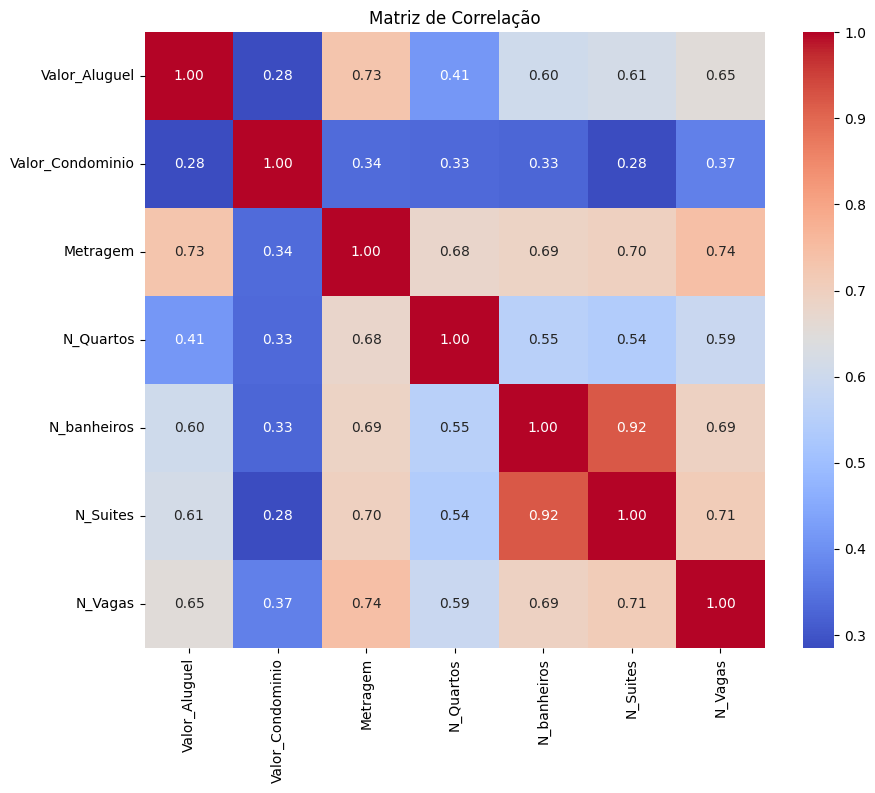

In [16]:
correlation_matrix = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

Variáveis com maior correlação:
- N_Suites com N_Banheiros
- N_Vagas com Metragem 
- Metragem com valor_Aluguel
- N_Vagas com N_Suites
- N_Banheiros com N_Vagas

In [17]:
X = df.drop('Valor_Aluguel', axis=1)
y = df['Valor_Aluguel']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [19]:
print('Tamanho de X_train:', X_train.shape)
print('Tamanho de X_test:', X_test.shape)
print('Tamanho de y_train:', y_train.shape)
print('Tamanho de y_test:', y_test.shape)

Tamanho de X_train: (5402, 6)
Tamanho de X_test: (1801, 6)
Tamanho de y_train: (5402,)
Tamanho de y_test: (1801,)


### Modelo de regressão Linear simples:

In [20]:
X = X_train[['Metragem']]
y = y_train

In [21]:
regressao = LinearRegression()

regressao.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
regressao.intercept_

np.float64(-103.17820863080169)

In [23]:
regressao.coef_

array([34.70818769])

Equação: **Valor_Aluguel = intercepto + coeficiente × Metragem**

In [24]:
regressao.score(X,y)

0.5213271756253639

O coeficiente de determinação R² de 0.52 indica que apenas 52% da variação na variável dependente é explicada pela variável indenpendente. Ou seja, o modelo não é eficaz na previsão dos valores, isso indica que ele precisa de um refinamento e treinamento maior.

### Coeficiente de determinação (R²)

Se o valor do coeficiente de determinação (R²) para os dados de treinamento for melhor (ou seja, mais próximo de 1) do que o R² para os dados de teste, isso sugere que o modelo está superajustado aos dados de treinamento. Isso significa que o modelo pode estar se ajustando muito bem aos padrões específicos nos dados de treinamento, mas pode não generalizar bem para novos dados que não foram vistos durante o treinamento.

Por outro lado, se o R² para os dados de teste for melhor do que o R² para os dados de treinamento, isso pode ser indicativo de que o modelo está subajustado. Isso significa que o modelo não está se ajustando adequadamente aos padrões nos dados de treinamento e não está capturando a relação entre as variáveis independentes e dependentes de forma eficaz.

Idealmente, gostaríamos que o valor do R² fosse consistente entre os dados de treinamento e teste, indicando que o modelo é capaz de generalizar bem para novos dados. Se houver uma grande diferença entre os valores de R² para os dados de treinamento e teste, isso sugere que o modelo pode precisar de ajustes para melhorar sua capacidade de generalização.

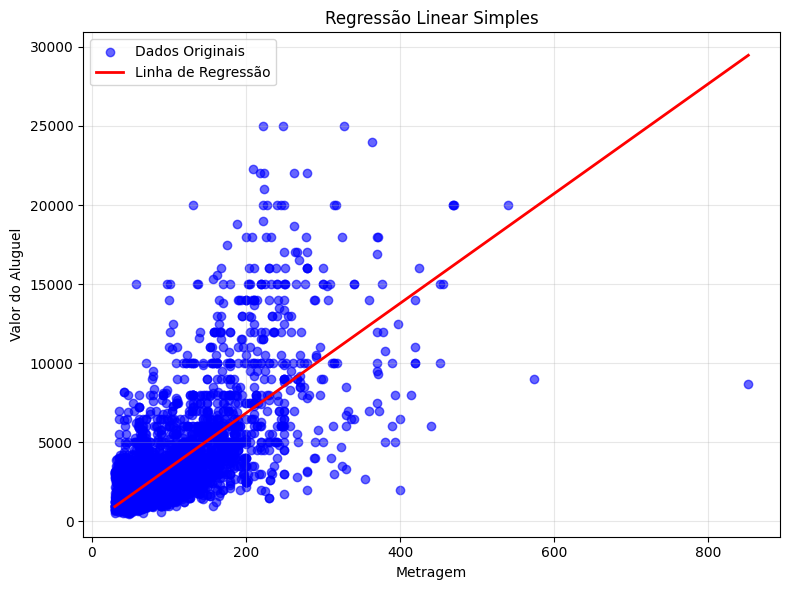

In [25]:
plt.figure(figsize=(8, 6))

# Dados originais
plt.scatter(X['Metragem'], y, color='blue', alpha=0.6, label='Dados Originais')

# Linha de regressão
X_ordenado = X.sort_values('Metragem')

plt.plot(X_ordenado['Metragem'], regressao.predict(X_ordenado), color='red', linewidth=2, label='Linha de Regressão')

plt.xlabel('Metragem')
plt.ylabel('Valor do Aluguel')
plt.title('Regressão Linear Simples')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

O gráfico mostra que, embora alguns pontos estejam próximos à reta de regressão, grande parte dos valores apresenta um distanciamento significativo em relação a ela. Essa dispersão indica que a variável Metragem, utilizada isoladamente, não explica suficientemente as variações no valor do aluguel, o que contribui para o baixo coeficiente de determinação (R²). Isso sugere que outros fatores, como número de quartos, suítes, banheiros e vagas de garagem, também influenciam o preço e podem melhorar a capacidade preditiva do modelo.

In [26]:
X_test = X_test[['Metragem']]
y_test = y_test

In [27]:
previsoes = regressao.predict(X_test)

# Avaliando o desempenho do modelo usando métricas como o R²
r2 = regressao.score(X_test, y_test)

print("Coeficiente de Determinação (R²) nos Dados de Teste:", r2)
previsoes

Coeficiente de Determinação (R²) nos Dados de Teste: 0.5651600449476675


array([1632.23117575, 1632.23117575, 1909.89667725, ..., 4998.92538145,
       1736.35573881, 1944.60486494], shape=(1801,))

O coeficiente de determinação (R²) obtido nos dados de teste foi de aproximadamente 0.56, indicando que o modelo consegue explicar cerca de 56,5% da variação nos valores de aluguel com base na variável Metragem. Esse resultado foi superior ao obtido nos dados de treinamento, sugerindo que o modelo apresentou um desempenho melhor no conjunto de teste. Entretanto, essa diferença, por si só, não garante uma boa capacidade de generalização, pois o desempenho pode variar conforme a divisão dos dados. Além disso, o resultado indica que outros fatores, além da metragem, também influenciam os valores de aluguel e poderiam contribuir para melhorar as previsões.

### Modelo de regressão linear multipla:

In [28]:
X = df[['Valor_Condominio', 'Metragem', 'N_Quartos', 'N_banheiros', 'N_Suites', 'N_Vagas']]
y = df['Valor_Aluguel']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [30]:
regressao_multipla = LinearRegression()
regressao_multipla.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [31]:
regressao_multipla.coef_

array([ 2.38100085e-01,  2.80624859e+01, -7.78188142e+02,  2.41199988e+02,
        3.33895811e+02,  6.56564623e+02])

In [32]:
regressao_multipla.intercept_

np.float64(331.1043226273964)

In [33]:
regressao_multipla.score(X,y)

0.5920613818115257

O coeficiente de determinação (R²) de aproximadamente 0.59 indica que o modelo consegue explicar cerca de 59% da variação nos valores de aluguel com base nas variáveis independentes utilizadas, como metragem, valor do condomínio, número de quartos, banheiros, suítes e vagas de garagem.

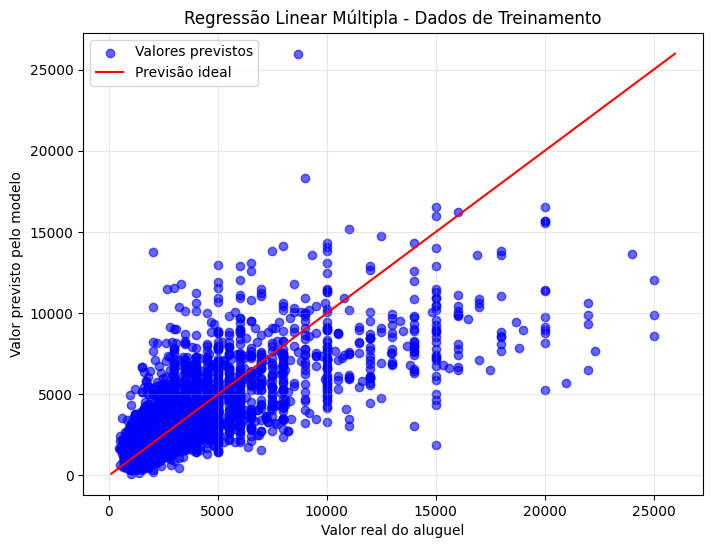

In [34]:
previsoes_treino = regressao_multipla.predict(X_train)

plt.figure(figsize=(8, 6))

plt.scatter(y_train, previsoes_treino, color='blue', alpha=0.6, label='Valores previstos')

# Linha de referência: previsão perfeita
minimo = min(y_train.min(), previsoes_treino.min())
maximo = max(y_train.max(), previsoes_treino.max())

plt.plot([minimo, maximo], [minimo, maximo], color='red', label='Previsão ideal')

plt.xlabel('Valor real do aluguel')
plt.ylabel('Valor previsto pelo modelo')
plt.title('Regressão Linear Múltipla - Dados de Treinamento')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

O gráfico apresenta a comparação entre os valores reais dos aluguéis e os valores previstos pelo modelo de regressão linear múltipla durante o treinamento. A linha vermelha representa a previsão ideal, na qual os valores previstos seriam iguais aos valores reais. Observa-se que muitos pontos estão relativamente próximos dessa linha, principalmente para imóveis com valores de aluguel mais baixos, indicando que o modelo consegue realizar previsões razoáveis para parte dos dados. Entretanto, à medida que os valores reais aumentam, nota-se uma maior dispersão dos pontos em relação à linha de referência, evidenciando diferenças entre os valores observados e os previstos. Em alguns casos, o modelo subestima ou superestima consideravelmente o valor do aluguel. Portanto, embora a utilização de múltiplas variáveis contribua para explicar os preços dos imóveis, o gráfico indica que o modelo ainda apresenta limitações na precisão das previsões, especialmente para imóveis com aluguéis mais elevados.

In [35]:
previsoes = regressao_multipla.predict(X_test)

r2 = regressao_multipla.score(X_test, y_test)

print("Coeficiente de Determinação (R²) nos Dados de Teste:", r2)
previsoes

Coeficiente de Determinação (R²) nos Dados de Teste: 0.6144317542526898


array([1190.8573857 , 1237.52500232, 1875.21263108, ..., 5243.4477312 ,
       1314.56945744, 1903.27511697], shape=(1801,))

O coeficiente de determinação (R²) obtido nos dados de teste foi de aproximadamente 0.61, indicando que o modelo de regressão linear múltipla consegue explicar cerca de 61,4% da variação nos valores de aluguel com base nas variáveis independentes utilizadas. Esse resultado foi superior ao obtido nos dados de treinamento, sugerindo que o modelo apresentou um desempenho melhor no conjunto de teste.

### Comparando os resultados dos modelos

Ao comparar os modelos de regressão linear simples e múltipla, observa-se que a regressão múltipla apresentou um desempenho superior na previsão dos valores de aluguel. Enquanto o modelo simples, que utiliza apenas a metragem do imóvel como variável independente, obteve um R² de aproximadamente 0.57 nos dados de teste, o modelo múltiplo alcançou cerca de 0.61, considerando também variáveis como valor do condomínio, número de quartos, banheiros, suítes e vagas de garagem.

Dessa forma, o modelo múltiplo conseguiu explicar aproximadamente 61,4% da variação nos valores de aluguel, enquanto o modelo simples explicou cerca de 56,5%. Essa diferença indica que a inclusão de outras características dos imóveis contribuiu para melhorar a capacidade explicativa do modelo. Entretanto, ambos ainda apresentam limitações, sugerindo que outros fatores também podem influenciar os preços dos aluguéis e que há espaço para aprimorar as previsões.